In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv

%load_ext autoreload
%autoreload 2

# 1. Creation of transducer object

The transducer definitions are saved in the module call transducers, on can import this module in a python .py script or a notebook, and print the available options as follows:

In [2]:
import pyfield.transducers as transducers

transducers.available_transducers()

['LinearArrayTransducer', 'MatrixArrayTransducer', 'Domino', 'Zeus_Matrix']

## 1.1. Linear Array Transducer

There is a general function to create a LinearArrayTransducer and MatrixArrayTransducer with any custom geometry. The 'Domino' and 'Zeus_Matrix' are presaved linear and matrix arrays. 
Let's see what we have to define into the linear array transducer:

In [3]:
# Create transducer with elevation focus
n_elements = 128
pitch_mm = 0.11
element_width_mm = 0.108
element_height_mm = 1.5
elevation_focus_mm = 8  # mm
tx_freq = 12.5  # MHz

MyTransducer = transducers.LinearArrayTransducer(
    n_elements         = n_elements,
    element_width_mm   = element_width_mm,
    element_height_mm  = element_height_mm,
    elevation_focus_mm = elevation_focus_mm,
    kerf_mm            = pitch_mm - element_width_mm,
    no_sub_x           = 1,
    no_sub_y           = 10,
    frequency_Hz       = tx_freq*1e6,  # MHz),
    )

LinearArrayTransducer initialized in 0.0100 seconds.


The definition of transducers is intended to be similar to the one already created in FIELDII matlab program, so the transition from FIELDII to this python simulator is smooth. One can directly see the created transducer as follows:

In [4]:
MyTransducer.show()  # visualize transducer geometry


The last code should pop up a window for visualization of the transducer. If you want to visualize them in the jupyter notebook, use the next input : 

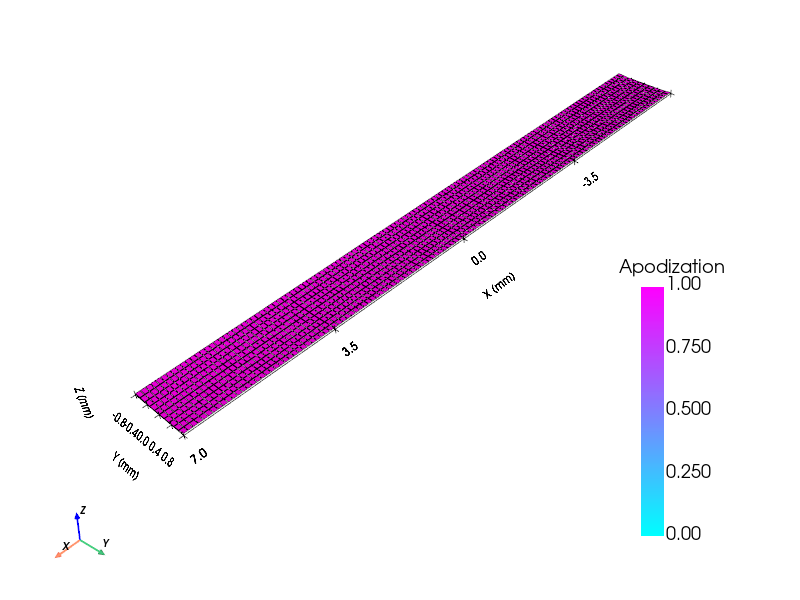

In [5]:
MyTransducer.show(notebook=True, jupyter_backend='static')  # visualize transducer geometry

In the next cell we will see how we can compute the delay law and apodization for an intended focalization :

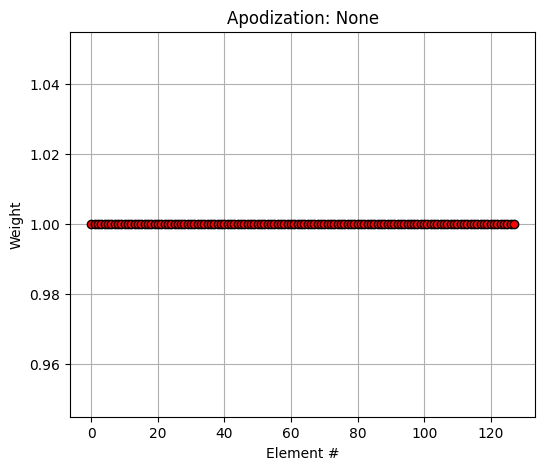

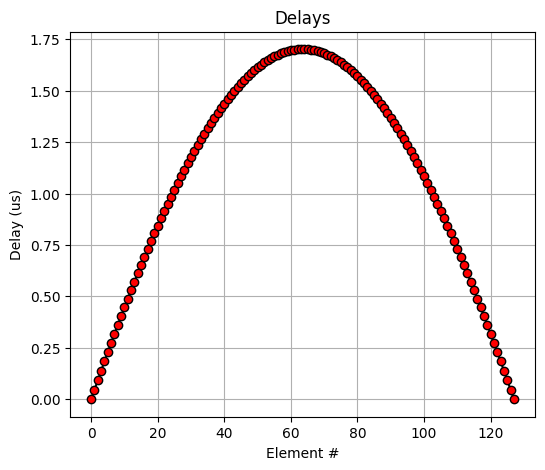

In [6]:
focus_mm = [0, 0, 8]  # x,y,z

apodization = MyTransducer.compute_apodization(focus_mm=focus_mm, plot = True)
delays = MyTransducer.compute_delays(focus_mm=focus_mm, plot = True)



Note that if you call the module 'compute_apodization' it will create and apodization by default of FoverD and with rectangular apodization, and will be assigned to the transducer. Look:

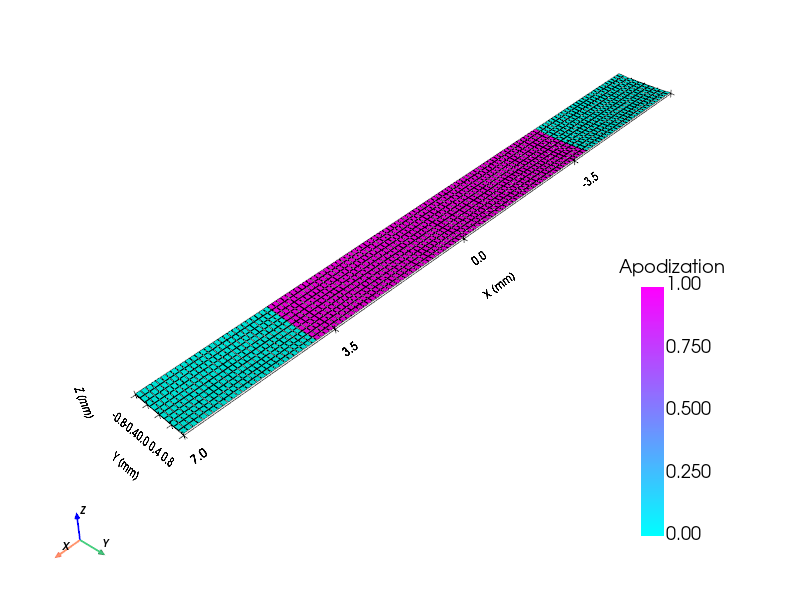

In [7]:
MyTransducer.show(notebook=True, jupyter_backend='static')  # visualize transducer geometry

One could change the type of apodization, like this:

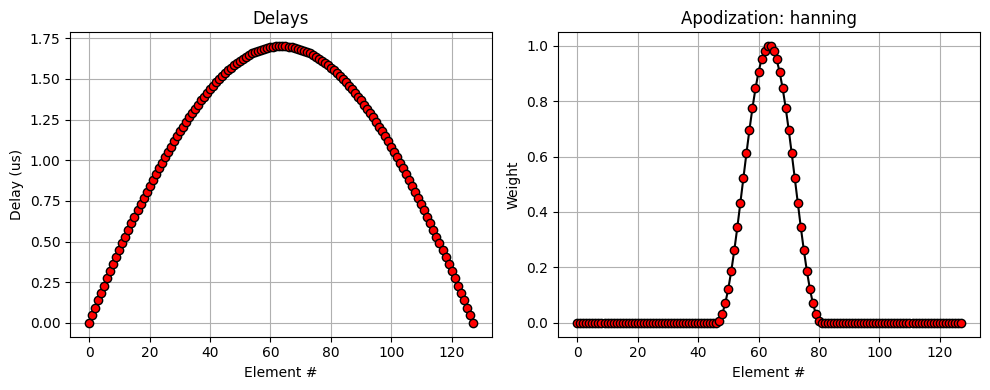

In [8]:
apodization_type = "hanning"  # "none", "rect", "hanning", "hamming"
FoverD = 2 

apodization = MyTransducer.compute_apodization(focus_mm=focus_mm, FoverD=FoverD, apodization_type=apodization_type)
MyTransducer.plot_delays_apodization()

Or set a custom apodization :

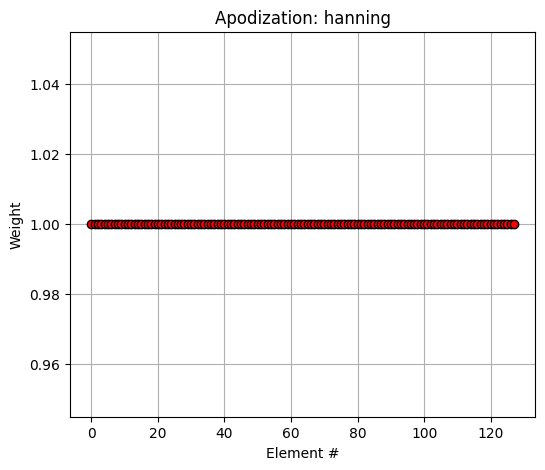

In [9]:
apodization = np.ones(n_elements)

MyTransducer.set_apodization(apodization)
MyTransducer.plot_apodization()


Note that this did not change anything in the delays of the transducer:

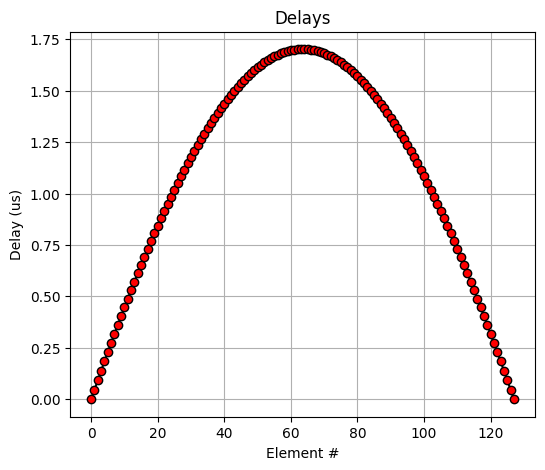

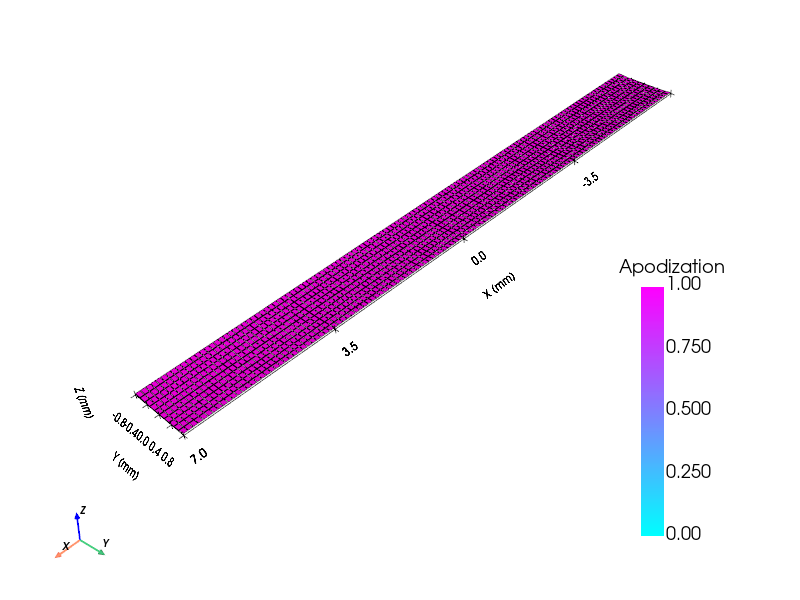

In [10]:
MyTransducer.plot_delays()
MyTransducer.show(notebook=True, jupyter_backend='static')  # visualize transducer geometry

By default, the transducer will be colored with the apodization. However, it is possible to change this to visualize the delay law.

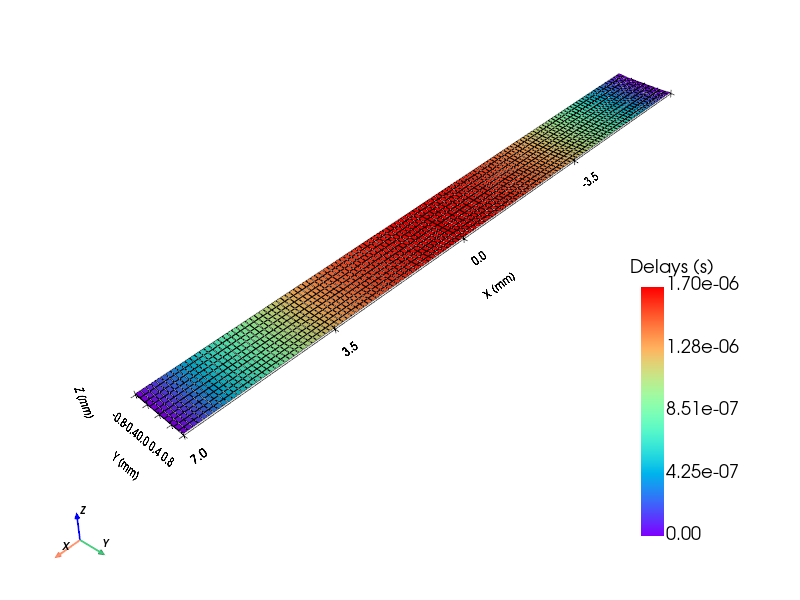

In [11]:
MyTransducer.show(notebook=True, jupyter_backend='static', scalars="Delays")  # visualize transducer geometry

# 2. Simulation of pressure field

In [12]:
import pyfield

# Option A - using the psimulation package re-exports
from pyfield.psimulation import PyField, TorchField

# Option B - explicit import from module file
from pyfield.psimulation.PyField import PyField
from pyfield.psimulation.TorchField import TorchField

# Option C - explicit call the function from pyfield
# PyField(tx) => pyfield.PyField(tx)

import pyfield.transducers as transducers


## 2.1. Linear array transducer

In [13]:
focus_mm = np.array([0, 0, 8])


MyTransducer = transducers.Domino()
delays = MyTransducer.compute_delays(focus_mm=focus_mm)

# apodization = MyTransducer.compute_apodization(
#     focus_mm=focus_mm, FoverD=1, apodization_type="rect"
# )

field_info_mm = {
    "x_extent": [-0.25 + focus_mm[0], 0.25 + focus_mm[0]],
    "y_extent": [-0.5 + focus_mm[1], 0.5 + focus_mm[1]],
    "z_extent": [-1 + focus_mm[2], 1 + focus_mm[2]],
    "dx": 0.0125,
    "dy": 0.025,
    "dz": 0.05,
}

LinearArrayTransducer initialized in 0.0026 seconds.


In [14]:
# Use TorchField to compute the pressure field
MyTransducer_Pyfield = pyfield.PyField(MyTransducer)

x, y, z, pressure_field = MyTransducer_Pyfield(field_info_mm, method = 'sdi')

Computing SIR for 68921 points and 1280 patches...
Max distance: 11.58 mm, Min distance: 6.97 mm
Computed time grid from 4.44 us to 9.31 us, with 973 samples in 1.63 seconds.
Transducer SIR computed in 5.69 seconds...
Pressure computed from SIR in 0.36 seconds...
Pressure field computed in 6.08 seconds...


Taking slice (0.0,0.0,8.0) => x_ind, y_ind, z_ind = 21/41, 21/41, 21/41


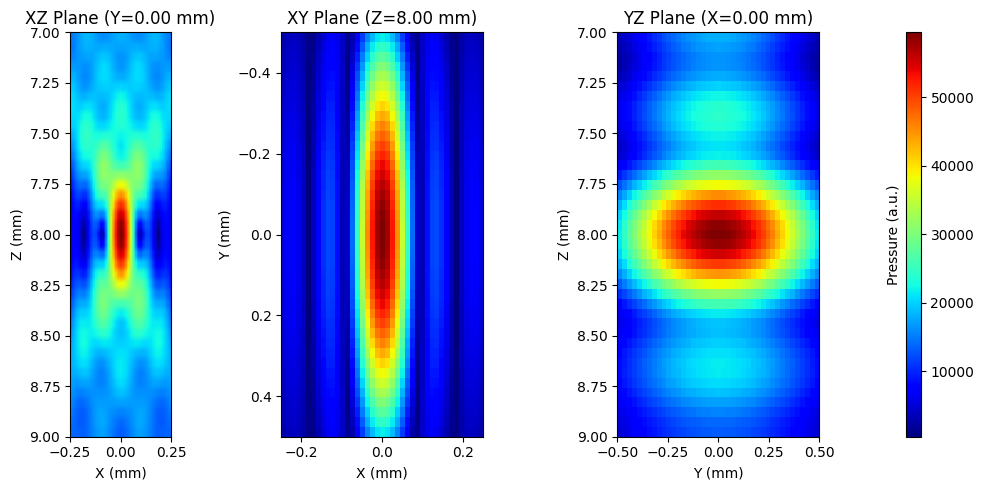

In [15]:
pyfield.plot_field_planes(x, y, z,pressure_field)

## 2.2. Matrix transducer

In [16]:
x_half_size_mm = 0.3
y_half_size_mm = 0.3
z_half_size_mm = 1
x_extent_mm = [-x_half_size_mm+focus_mm[0], x_half_size_mm+focus_mm[0]]
y_extent_mm = [-y_half_size_mm+focus_mm[1], y_half_size_mm+focus_mm[1]]
z_extent_mm = [-z_half_size_mm +focus_mm[2], z_half_size_mm+focus_mm[2]]
dx_mm = 0.025
dy_mm = 0.025
dz_mm = 0.05

x = np.linspace(x_extent_mm[0], x_extent_mm[1], int((x_extent_mm[1]-x_extent_mm[0])/dx_mm)+1)
y = np.linspace(y_extent_mm[0], y_extent_mm[1], int((y_extent_mm[1]-y_extent_mm[0])/dy_mm)+1)
z = np.linspace(z_extent_mm[0], z_extent_mm[1], int((z_extent_mm[1]-z_extent_mm[0])/dz_mm)+1)
field_info_mm = np.array(np.meshgrid(x, y, z)).T.reshape(-1, 3)
print(f"Number of field points: {field_info_mm.shape[0]}")
print(f"Field points from {field_info_mm.min(axis=0)} mm to {field_info_mm.max(axis=0)} mm")

Number of field points: 23616
Field points from [-0.3 -0.3  7. ] mm to [0.3 0.3 9. ] mm


In [17]:
focus_mm = np.array([0, 0, 8])

MyMatrixTransducer = transducers.Zeus_Matrix()

delays = MyMatrixTransducer.compute_delays(focus_mm=focus_mm)

apodization = MyMatrixTransducer.compute_apodization(
    focus_mm=focus_mm, FoverD=1, apodization_type="circular"
)

MyMatrixTransducer.show(notebook=False, jupyter_backend='static')  # visualize transducer geometry

MatrixArrayTransducer initialized with 3025 elements and 12100 patches.
Transducer initialized in 0.0623 seconds.


In [19]:
MyMatrixTransducer_Pyfield = PyField(MyMatrixTransducer)
MyMatrixTransducer_Torchfield = TorchField(MyMatrixTransducer)

GPU is available: cuda:NVIDIA GeForce RTX 4070 SUPER
Using device: cuda:0


In [20]:
x1, y1, z1, pressure_field1 = MyMatrixTransducer_Pyfield(field_info_mm)
x2, y2, z2, pressure_field2 = MyMatrixTransducer_Torchfield(field_info_mm)

Computing SIR for 23616 points and 12100 patches...
Max distance: 14.99 mm, Min distance: 7.00 mm
Computed time grid from 4.45 us to 13.70 us, with 1851 samples in 0.08 seconds.
Transducer SIR computed in 4.16 seconds...
Pressure computed from SIR in 0.27 seconds...
Pressure field computed in 4.57 seconds...
Computing field for 23616 points and 12100 patches, WITHOUT gradients in cuda:0.
Time range: 4.45 us to 13.70 us, with 1851 samples.


Computing SIR: 100%|██████████| 12/12 [00:02<00:00,  4.98batch/s]


Spatial impulse response computed in 2.68 seconds with batch size 2048.
Looking for fc: 10000000.0 Hz, found : 10048622.0 Hz, in 0.56 seconds.
Transformed from SIR to Pressure in 0.81 seconds.
Pressure field computed in: 3.5264 seconds, using cuda:0.


Taking slice (0.013043478260869545,0.013043478260869545,8.0) => x_ind, y_ind, z_ind = 13/24, 13/24, 21/41


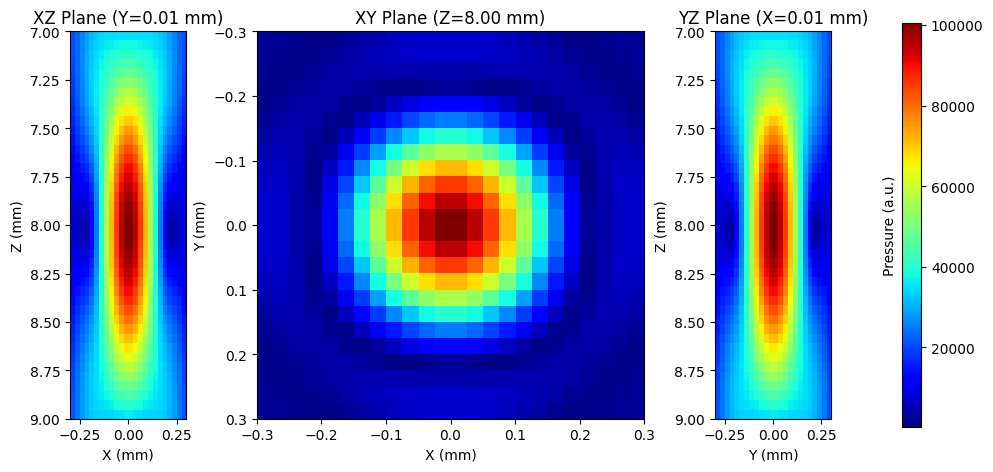

Taking slice (0.01304347813129425,0.01304347813129425,8.0) => x_ind, y_ind, z_ind = 13/24, 13/24, 21/41


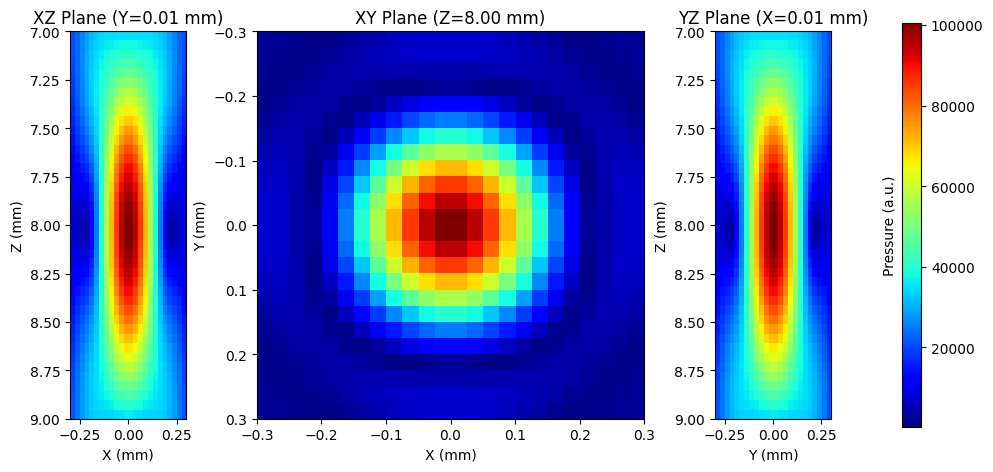

In [22]:
pyfield.plot_field_planes(x1, y1, z1,pressure_field2)
pyfield.plot_field_planes(x2, y2, z2,pressure_field2)